:::{admonition} Run this notebook yourself!
:class: important

Download the executed notebook: **{nb-download}`adversarial_examples_mad.ipynb`**!

Run it in your browser: **{binder}`adversarial_examples_mad.ipynb`**!

:::

(adversarial-examples-mad)=
# Synthesize adversarial examples using MAD Competition

:::{warning}
This notebook requires the optional dependency `torchvision`, which can be installed with `pip`.
:::

In this notebook we demonstrate how we can use the {class}`~plenoptic.MADCompetition` class to synthesize adversarial examples. Adversarial examples are images with subtle, imperceptible perturbations designed to deceive a Deep Neural Networks into making an incorrect classification ({cite:alp}`Szegedy2013`, {cite:alp}`goodfellow_explaining_2015`). MAD competition was developed to compare image quality metrics by generating a pair of images that have the same value for a reference metric but extremal values (highest and lowest) for an optimized metric ({cite:alp}`Wang2008-maxim-differ`). These images were then used as stimuli in psychophysics experiments, to demonstrate which metric best aligned with human perception. Here, we demonstrate a different use of the {class}`~plenoptic.MADCompetition` class and show how its underlying machinery can be readily used to generate adversarial examples of Deep Neural Networks.

See [](adversarial-examples-metamer) for an alternate approach to synthesizing adversarial examples using {class}`~plenoptic.MADCompetition`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from myst_nb import glue

import plenoptic as po

# this notebook uses torchvision, which is an optional dependency. if this import fails,
# install torchvision in your plenoptic environment and restart the notebook kernel.
try:
    import torchvision
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "optional dependency torchvision not found!"
        " please install it in your plenoptic environment "
        "and restart the notebook kernel"
    )


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72

# set seed for reproducibility
po.set_seed(4)
# To guarantee reproducibility for this example on the GPU, we must tell torch to use
# deterministic algorithms -- the default behavior for convolution is non-deterministic.
# Note this will make things slower! See "Reproducibility and Compatibility" in the docs
# for more details.
torch.use_deterministic_algorithms(True)

## Prepare model and image for synthesis

In the following block, we create a {class}`~plenoptic.models.DeepNetFeatures` model matching the output of the final fully connected layer of a classic image recognition network, [ResNet50](https://en.wikipedia.org/wiki/Residual_neural_network), trained to classify images into one of [1000 categories](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/). We chose the final layer to attack because the goal is misclassification and the final fully-connected layer corresponds to the probabilities of the categories. After creating the model, we then prepare the image. Finally, we ensure that the model and image have the proper device and dtype, and remove the gradient from all model parameters.

To learn more about any of these steps and why we take them, read [](deep_nets).

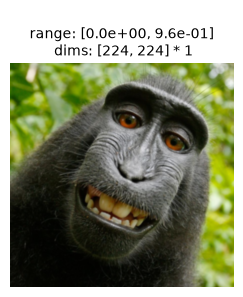

In [2]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
deepnet = torchvision.models.resnet50(weights=weights)
deepnet.eval()
transform = weights.transforms()
norm = torchvision.transforms.Normalize(transform.mean, transform.std)
target_layer = "fc"
model = po.models.DeepNetFeatures(deepnet, target_layer, norm)

img = po.data.macaque()
img = po.process.blur_downsample(img, 2)[..., :-59, :]
img = po.process.center_crop(img, transform.crop_size[0])
po.plot.imshow(img, as_rgb=True)

img = img.to(DEVICE).to(torch.float64)  # convert to float64 for reproducibility
model.to(DEVICE).to(torch.float64)
deepnet.to(DEVICE).to(torch.float64)

# remove the gradient from all model parameters
po.remove_grad(model)

## Visualizing classification of the clean image
First let us extract all the [ImageNet-1K](https://en.wikipedia.org/wiki/ImageNet#ImageNet-1K) categories:

In [3]:
imagenet_categories = np.asarray(weights.meta["categories"])

Let us define three helper functions:
- `convert_to_probs` converts the activation in the final fully-connected layer to probabilities that sum to 1. It gets used in `get_category`, below.
- `get_category` accepts a single image and returns both a vector containing the category probabilities and name of the category with the highest probability.
- `get_likely_categories` accepts the category probabilities and returns all categories with probability higher than 0.01.

In [4]:
def convert_to_probs(logits):
    return torch.nn.functional.softmax(logits, dim=1).squeeze()


def get_category(image):
    category_probs = convert_to_probs(deepnet(norm(image))).detach().cpu()
    category = imagenet_categories[category_probs.argmax()]
    return category_probs, category


def get_likely_categories(category_probs):
    likely_idx = torch.where(category_probs > 0.01)[0]
    likely_idx = likely_idx[torch.argsort(category_probs[likely_idx], descending=True)]
    likely_cats = imagenet_categories[likely_idx].tolist()
    if isinstance(likely_cats, str):
        likely_cats = [likely_cats]
    return "\n".join(f"- {cat}" for cat in likely_cats)

The following plot shows the classification probabilities for the original image as a stem plot. Each of the 1000 categories is represented by a line, whose y-value gives the model's probability that the image belongs to the corresponding category (the x-value is arbitrary). The title shows the label of the most likely category, and the text on the plot shows the other categories with probability higher than 0.01.

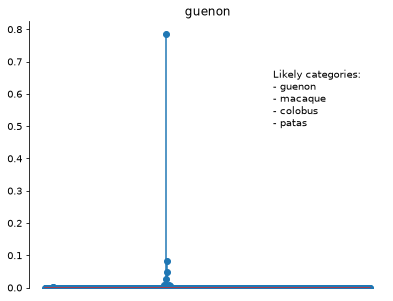

In [5]:
category_probs, category = get_category(img)
po.plot.stem_plot(category_probs, title=category)
likely_cats = get_likely_categories(category_probs)
plt.text(700, 0.5, f"Likely categories:\n{likely_cats}");

The category of our initial image, [guenon](https://en.wikipedia.org/wiki/Guenon), is an Old World monkey. Though it isn't the actual species of the monkey in question (a [Celebes crested macaque](https://en.wikipedia.org/wiki/Celebes_crested_macaque)), it's a reasonable category for it. Notice the model is highly confident in its classification, with a probability of about 0.8 and no other category exceeding a probability of 0.1. The other predicted categories are all [Old World monkeys](https://en.wikipedia.org/wiki/Old_World_monkey).

## Define optimized and reference metric

To qualify as an adversarial example, the image must satisfy two requirements: (1) the perturbation in image space is small and (2) the model outputs an incorrect classification with high confidence ({cite:alp}`goodfellow_explaining_2015`). Conveniently, we already have these two ingredients built into the MAD competition framework. More concretely, we should be able to meet these two requirements if we define:

1. The reference metric as a distance in pixel space and set it to a low value.
2. The optimized metric as a distance in representation space, so that we synthesize an image whose representation is as far away from the original as possible.

For the reference metric, we use mean-squared-error (MSE):

In [6]:
def reference_metric(x, y):
    # compute MSE independently per RGB channel and then average.
    return po.metric.mse(x, y).mean()

For the optimized metric, we use MSE on the activations of the last fully-connected layer of the network.

In [7]:
def optimized_metric(x, y):
    return po.metric.mse(model(x), model(y))

:::{admonition} Why not define the optimized metric on probabilities?
:class: dropdown hint

While a vector of probabilities (`convert_to_probs(model(x))` instead of `model(x)`) is the more natural way to think about the output of the network, [logits](https://en.wikipedia.org/wiki/Logit) (the representation before calling `softmax`) provide the smooth and differentiable gradients necessary for well-behaved optimization. In particular, since many of the initial image's classification probabilities are exactly zero, optimizing on the probabilities means the resulting adversarial example will never be classified as one of those classes (since the gradients are zero).
:::

## Synthesize the adversarial image

We want to maximize {attr}`~plenoptic.MADCompetition.optimized_metric` while holding {attr}`~plenoptic.MADCompetition.reference_metric` small. Therefore we set {attr}`~plenoptic.MADCompetition.minmax` to "max". {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` controls the relative weight of {attr}`~plenoptic.MADCompetition.optimized_metric_loss` and {attr}`~plenoptic.MADCompetition.reference_metric_loss` in the objective function. We found a {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` value of 1e10 generally produced good adversarial examples for the monkey image.

In [8]:
mad = po.MADCompetition(
    img, optimized_metric, reference_metric, minmax="max", metric_tradeoff_lambda=1e10
)

:::{admonition} How does {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` affect the adversarial image and how do I find a good one?
:class: dropdown hint

We conducted a hyperparameter search and found increasing {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` led to decrease in both {attr}`~plenoptic.MADCompetition.optimized_metric_loss` and {attr}`~plenoptic.MADCompetition.reference_metric_loss`. This makes intuitive sense as a larger penalty value increases the importance of keeping the reference metric constant, which inevitably prevents the optimized metric from increasing.

If you are applying this procedure to new images or new image classification models, you will almost certainly need to experiment to find the appropriate {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda`. Specifically, choose a {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` that maximizes {attr}`~plenoptic.MADCompetition.optimized_metric_loss` while minimizing {attr}`~plenoptic.MADCompetition.reference_metric_loss`.

:::
MAD competition synthesis begins by adding some Gaussian pixel noise to the original image and this is the initial image. Between the initial image and the original image, the reference metric is first calculated, whose value the optimization will try to keep constant over the course of the synthesis. We set the initial noise to be a small value so that our final synthesized image also has small deviations in the pixel values from the original. We also decreased the learning rate from the default, as this resulted in better solutions in our experiments.

In [9]:
mad.setup(initial_noise=0.001, optimizer_kwargs={"lr": 0.001})

Running the synthesis generates an image that looks just like the original image but we see the optimized metric loss has increased significantly (by two orders of magnitude). Even though the reference metric loss measured in pixel space has also increased, it remains a small value. The fact that the optimized metric has significantly increased shows that the model thinks this is a very different category than our initial image, which we'll show in the next section.

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05637793050589509..0.9674300485148172].


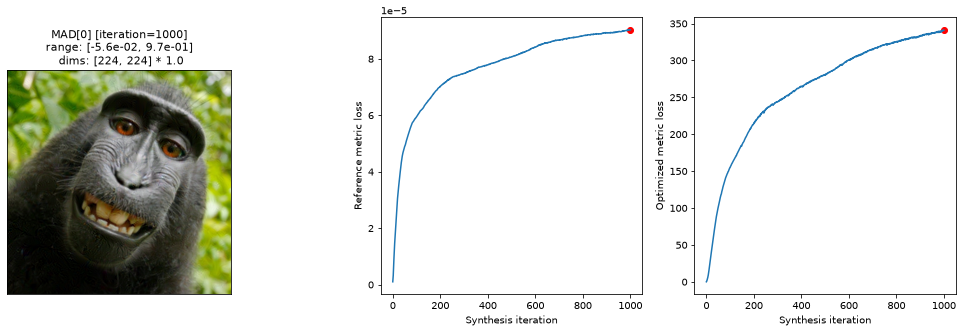

In [10]:
mad.synthesize(1000)
po.plot.synthesis_status(mad);

## Visualizing the adversarial image

First let us visualize the category probabilities of the original, initial, and adversarial images using stem plots.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0017865116235119814..0.9664144515791862].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05637793050589509..0.9674300485148172].


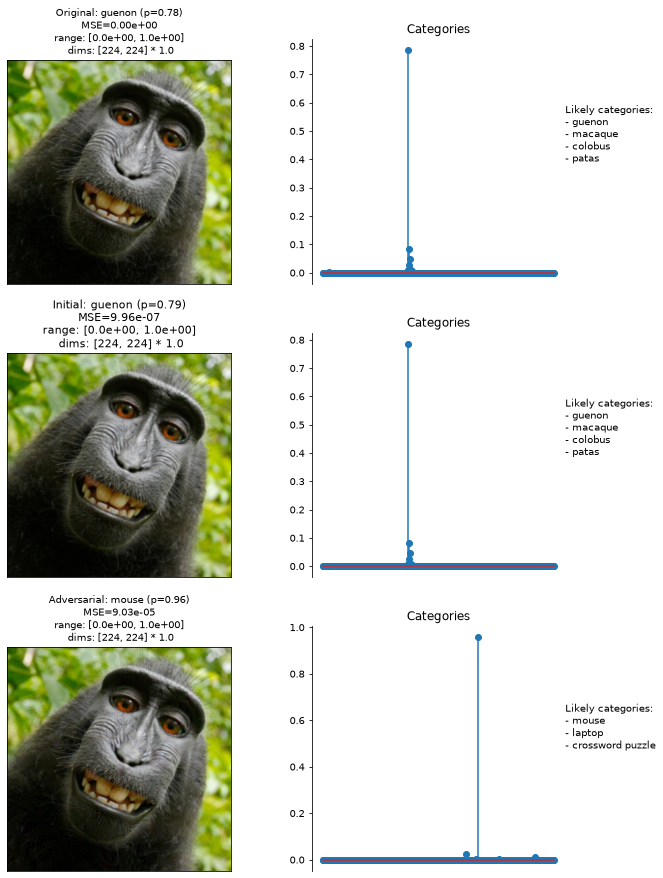

In [11]:
images = {"Original": img, "Initial": mad.initial_image, "Adversarial": mad.mad_image}
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
for i, name in enumerate(["Original", "Initial", "Adversarial"]):
    category_probs, category = get_category(images[name])
    likely_cats = get_likely_categories(category_probs)
    most_likely_cat = imagenet_categories[category_probs.argmax()]
    mse_val = po.metric.mse(images["Original"], images[name]).mean().item()
    title = (
        f"{name}: {most_likely_cat} (p={category_probs.max():.2f})\nMSE={mse_val:.2e}"
    )
    po.plot.imshow(
        images[name],
        ax=axes[i, 0],
        as_rgb=True,
        title=title,
        vrange=(0, 1),
    )
    po.plot.stem_plot(category_probs, ax=axes[i, 1], ylim=False)
    axes[i, 1].set_title("Categories")
    axes[i, 0].xaxis.set_visible(False)
    axes[i, 0].yaxis.set_visible(False)
    axes[i, 1].text(
        1, 0.5, f"Likely categories:\n{likely_cats}", transform=axes[i, 1].transAxes
    )
category_probs, category = get_category(mad.mad_image)
glue("category_name", str(category), display=False)

In the top row, we have the original image on the left and the stem plot on the right. The middle and bottom rows correspond to the initial image and the adversarial example, together with their stem plots. On top of each image, we show the MSE from the original image. The texts next to the stem plots show the most likely categories. We see the network is highly confident that the synthesized image is a {glue}`category_name`! We also see the MSE between the original and the synthesized images is still quite small, even though it increased compared to the initial image.

While the synthesized image is visually similar to the original image (note the low MSE with the original), let us verify more rigorously. In the bottow row,  the original image is subtracted from the initial image and synthesized image to visualize the changes in pixel values.

:::{admonition} Why are we rescaling the difference image?
:class: dropdown question
Since the individual image pixel values could have either increased or decreased over synthesis, the difference image contains both positive and negative values. However, visualizing RGB images requires all pixel values to lie between 0 and 1 (see {external+matplotlib:func}`matplotlib.pyplot.imshow` for more details). Therefore, we must rescale the pixel values' to lie between 0 and 1; we additionally use {func}`~plenoptic.process.rescale` to remap the minimum and maximum to be 0 and 1, respectively, to make the structure of the difference image more visible.
:::

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0017865116235119814..0.9664144515791862].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05637793050589509..0.9674300485148172].


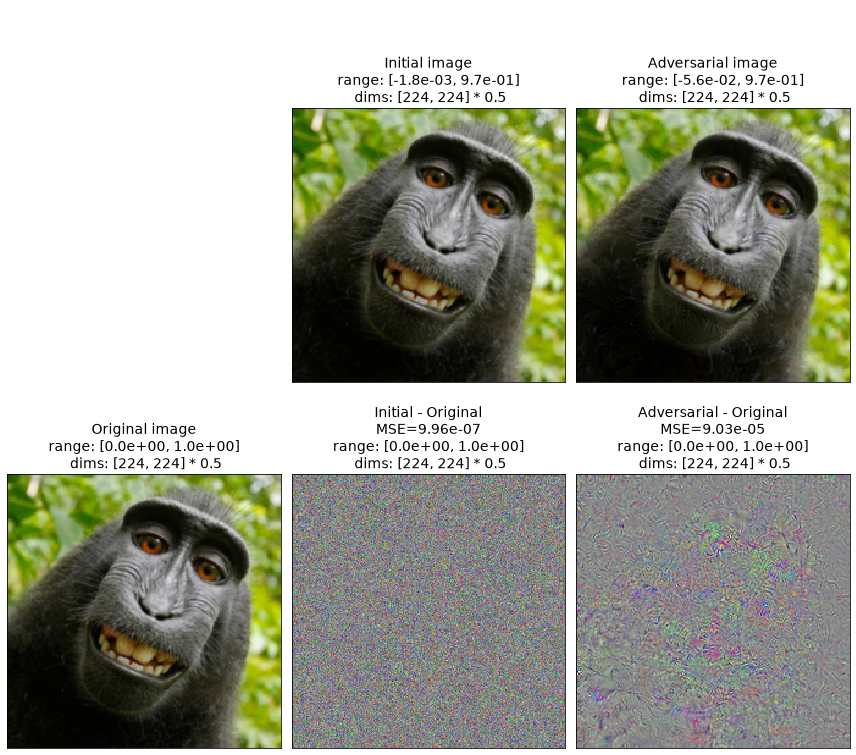

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 12))
axes[0, 0].axis("off")

po.plot.imshow(images["Initial"], ax=axes[0, 1], as_rgb=True, title="Initial image")
po.plot.imshow(
    images["Adversarial"], ax=axes[0, 2], as_rgb=True, title="Adversarial image"
)

po.plot.imshow(
    images["Original"],
    ax=axes[1, 0],
    as_rgb=True,
    title="Original image",
    vrange=(0, 1),
)

for j, col_name in enumerate(["Initial", "Adversarial"], start=1):
    diff = images[col_name] - images["Original"]
    diff_rescaled = po.process.rescale(diff)
    mse_val = po.metric.mse(images["Original"], images[col_name]).mean().item()
    po.plot.imshow(
        diff_rescaled,
        ax=axes[1, j],
        as_rgb=True,
        title=f"{col_name} - Original\nMSE={mse_val:.2e}",
    )

for ax in [axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]]:
    ax.set_title(ax.get_title(), fontsize=14)

for ax in axes.flat:
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

fig.tight_layout();

Between initial and original images, the difference looks like random pixel noise (middle panel, bottom row). Given that the initial image is the original plus normally-distributed noise, that must be true. The difference between synthesized and original images has more structure (right panel, bottom row) but it does not look like a {glue}`category_name`, or similar. Let us also visualize the difference in each color channel (red, green, and blue) separately, to see if there's any structure hiding there.

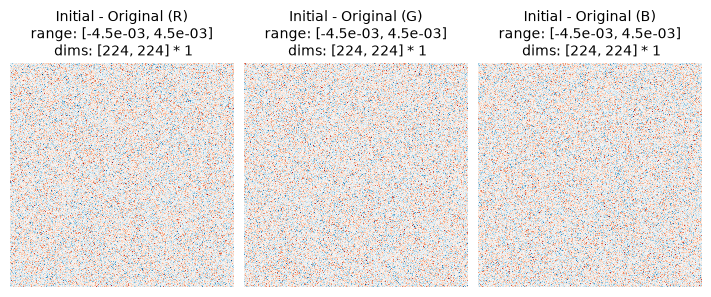

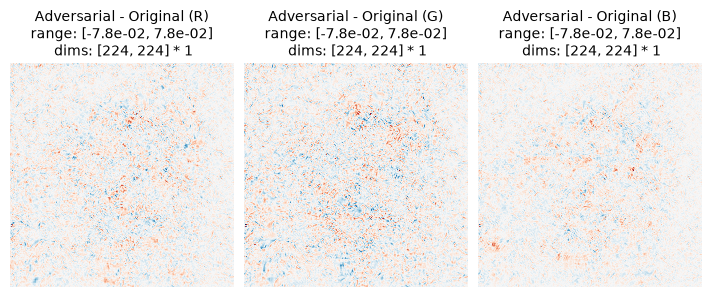

In [13]:
channelwise_diffs_initial = mad.initial_image - img
titles = ["Initial - Original (R)", "Initial - Original (G)", "Initial - Original (B)"]
po.plot.imshow(channelwise_diffs_initial, col_wrap=3, title=titles, vrange="auto0")
channelwise_diffs_mad = mad.mad_image - img
titles = [
    "Adversarial - Original (R)",
    "Adversarial - Original (G)",
    "Adversarial - Original (B)",
]
po.plot.imshow(channelwise_diffs_mad, col_wrap=3, title=titles, vrange="auto0");

In the top row, we can see that the difference between the initial and original images is noise, randomly distributed across the image, with no structure like before. In the bottom row, the pattern has shifted, with the differences grouping together somewhat (also note the pixel value range is different between the top and bottom rows). However, this difference does not look like a {glue}`category_name` either in any of the channels. At this point we can safely conclude the synthesized image is an adversarial example of the network.

This notebook demonstrates how to generate adversarial examples using the {class}`~plenoptic.MADCompetition` class. We encourage you to experiment with different image classification networks, images, and hyperparameters to generate other adversarial examples yourself!